# Multiple Linear Regression — Student Performance Index

Predicting a continuous `Performance Index` (0-100) from 5 study-related features, with full evaluation,
diagnostic plots, and a walk-through of what multiple regression is actually doing.

**Dataset:** 10,000 students — `Hours Studied`, `Previous Scores`, `Extracurricular Activities` (Yes/No),
`Sleep Hours`, `Sample Question Papers Practiced`, target `Performance Index`. No missing values.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

## 1. Load and inspect the data

In [2]:
df = pd.read_csv("Student_Performance.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (10000, 6)


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [3]:
print("--- Missing values ---")
print(df.isnull().sum())

--- Missing values ---
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


**Fix from the original notebook:** it wrote `null_values = df.isnull().sum` (missing the
parentheses), which assigns the method itself rather than calling it — printing that would show something
like `<bound method DataFrame.sum...>`, not actual counts. The next cell in the original notebook quietly
redid it correctly, so the broken version is simply not repeated here.

## 2. What multiple linear regression is doing

With one predictor, linear regression fits a line: $y = b_0 + b_1x_1$. With multiple predictors, it
fits a hyperplane — the same idea extended to more dimensions:

$$\text{Performance Index} = b_0 + b_1(\text{Hours Studied}) + b_2(\text{Previous Scores}) + b_3(\text{Extracurricular}) + b_4(\text{Sleep Hours}) + b_5(\text{Papers Practiced})$$

Each coefficient $b_i$ answers: *"holding every other feature constant, how much does the Performance
Index change for a one-unit increase in this feature?"* The model finds the coefficients that minimize the
total squared error between its predictions and the real performance index values across all 10,000
students. Those actual fitted coefficients are printed and interpreted in Section 6.

## 3. Encoding the categorical feature

In [4]:
le = LabelEncoder()
df["Extracurricular Activities"] = le.fit_transform(df["Extracurricular Activities"])
print("Encoding:", dict(zip(le.classes_, le.transform(le.classes_))))
# No -> 0, Yes -> 1

Encoding: {'No': np.int64(0), 'Yes': np.int64(1)}


This one is fine as-is — unlike the ordinal-encoding mistake covered in the feature-correlation
notebook earlier in this series, `LabelEncoder` on a **2-category** column doesn't manufacture a false
ordering. With only two classes, 0/1 encoding is mathematically identical to one-hot encoding — there's no
third category for a fake numeric distance to distort.

## 4. Exploratory visualization

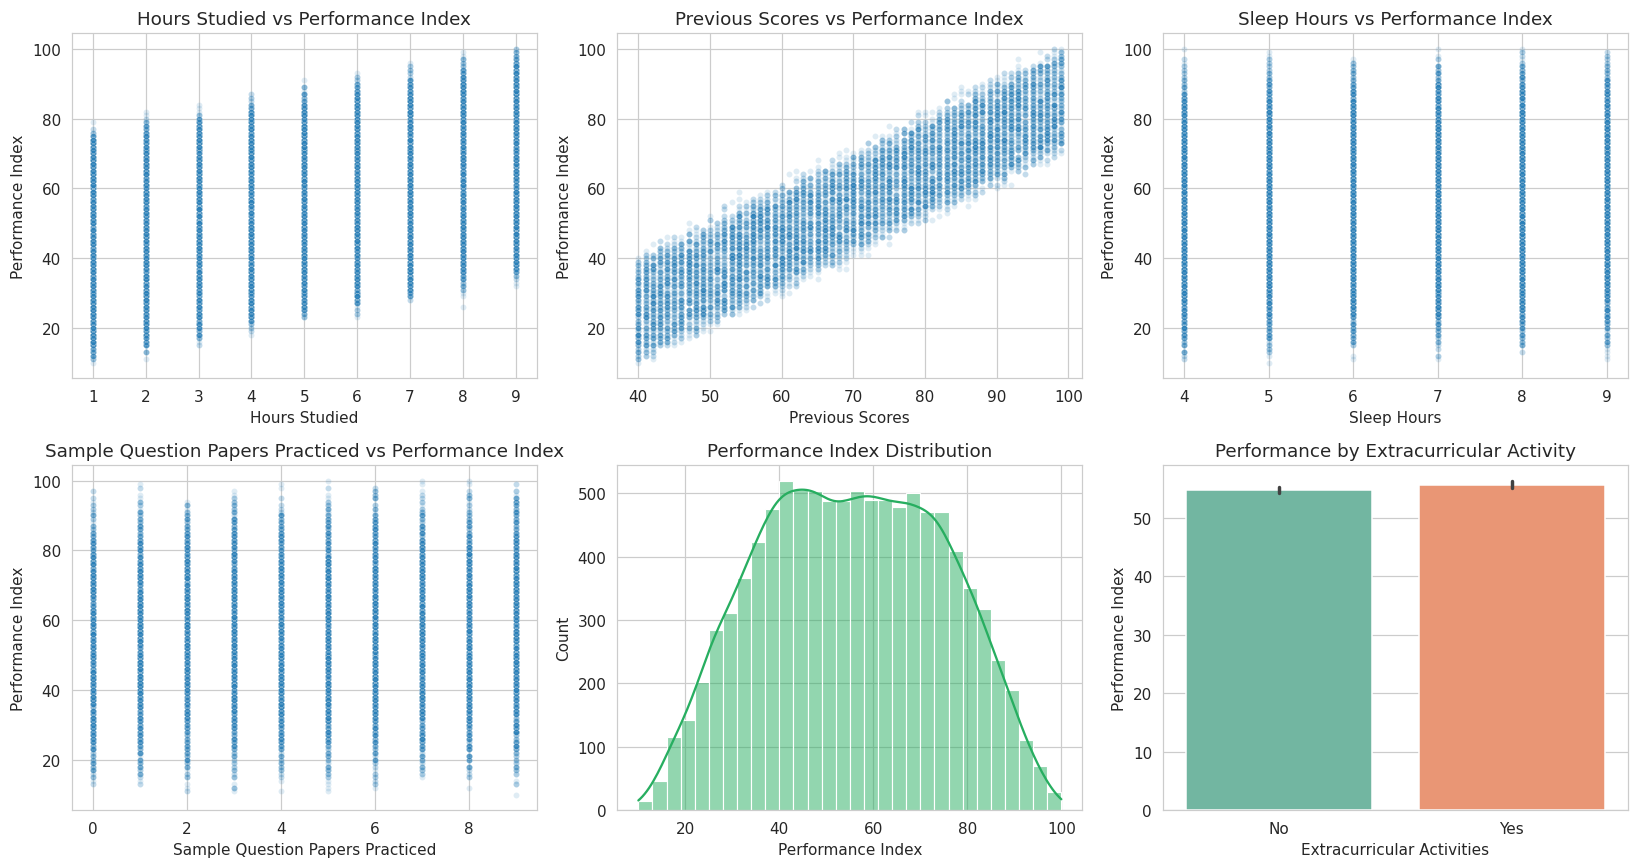

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features_to_plot = ["Hours Studied", "Previous Scores", "Sleep Hours",
                     "Sample Question Papers Practiced"]

for ax, feature in zip(axes.flat, features_to_plot):
    sns.scatterplot(data=df, x=feature, y="Performance Index", alpha=0.15,
                     color="#2980b9", ax=ax, s=15)
    ax.set_title(f"{feature} vs Performance Index")

sns.histplot(df["Performance Index"], bins=30, kde=True, color="#27ae60", ax=axes.flat[4])
axes.flat[4].set_title("Performance Index Distribution")

sns.barplot(data=df, x="Extracurricular Activities", y="Performance Index",
            hue="Extracurricular Activities", palette="Set2", legend=False, ax=axes.flat[5])
axes.flat[5].set_xticks([0, 1])
axes.flat[5].set_xticklabels(["No", "Yes"])
axes.flat[5].set_title("Performance by Extracurricular Activity")

plt.tight_layout()
plt.show()

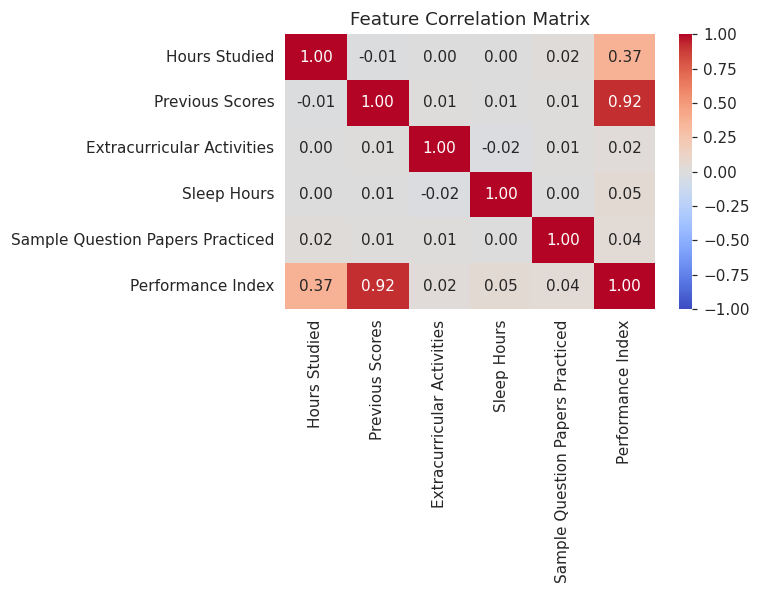

In [6]:
plt.figure(figsize=(7, 5.5))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

`Previous Scores` and `Hours Studied` show the clearest linear relationships with the target visually
— that lines up with what the fitted coefficients confirm below.

## 5. Checking for multicollinearity (VIF)

Before trusting individual coefficients in a multiple regression, it's worth checking whether the
predictors are too correlated *with each other* — if two features move together, the model can't cleanly
tell which one deserves credit, and coefficients become unstable. Variance Inflation Factor (VIF) measures
this per feature; values above ~5-10 signal a problem.

In [7]:
X_check = df[["Hours Studied", "Previous Scores", "Extracurricular Activities",
              "Sleep Hours", "Sample Question Papers Practiced"]]

# Correct VIF requires an intercept column, or values are misleadingly inflated
X_with_const = add_constant(X_check)
vif_data = pd.DataFrame({
    "feature": X_with_const.columns,
    "VIF": [variance_inflation_factor(X_with_const.values, i)
            for i in range(X_with_const.shape[1])]
})
vif_data

,feature,VIF
0,const,38.916475
1,Hours Studied,1.000478
2,Previous Scores,1.000326
3,Extracurricular Activities,1.000802
4,Sleep Hours,1.000600
5,Sample Question Papers Practiced,1.000557


All 5 features have VIF close to **1.0** — essentially no multicollinearity. That's a reassuring
result: it means each coefficient can be trusted to reflect that feature's own relationship with the
target, not a distorted number caused by overlapping information between features. (One easy-to-miss
detail: `variance_inflation_factor` needs an intercept/constant column added first, or the VIF numbers come
out misleadingly inflated — a common gotcha with this specific function.)

## 6. Train/test split and model training

In [8]:
X = df[["Hours Studied", "Previous Scores", "Extracurricular Activities",
        "Sleep Hours", "Sample Question Papers Practiced"]]
y = df["Performance Index"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE
)

reg = LinearRegression()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

## 7. Evaluation — the step the original notebook never actually did

The original notebook imported `r2_score` and `mean_squared_error`, computed `y_pred`, and then
never called either metric — there was no way to know from that notebook whether the model was any good.
That's fixed here with a full set of regression metrics.

In [9]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f"R\u00b2 Score: {r2:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.9890
MAE:  1.6090
MSE:  4.0666
RMSE: 2.0166


**R² = 0.989** means the model explains about 98.9% of the variance in Performance Index from these
5 features — an unusually strong result, but this is a clean, synthetic dataset (per its documented source)
without real-world messiness like measurement error or unmeasured confounders, which is exactly the kind
of data multiple linear regression fits best. **RMSE ≈ 2.0** means predictions are typically within about
2 points of the true 0-100 performance index.

## 8. Interpreting the coefficients

In [10]:
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Raw Coefficient": reg.coef_
}).sort_values("Raw Coefficient", ascending=False)

print(f"Intercept: {reg.intercept_:.3f}")
coeff_df

Intercept: -33.837


,Feature,Raw Coefficient
0,Hours Studied,2.858952
1,Previous Scores,1.015520
2,Extracurricular Activities,0.581713
3,Sleep Hours,0.479677
4,Sample Question Papers Practiced,0.190394


**Fix from the original notebook:** `coeff_df` was built but never actually printed anywhere — the
most interpretable part of a regression model ended up invisible. Displayed here, plus one more fix below:
raw coefficients aren't directly comparable in size, since the features are on very different scales
(Hours Studied: 1-9, Previous Scores: 40-99, Sleep Hours: 4-9). A raw coefficient of 2.86 for
`Hours Studied` and 0.19 for `Sample Question Papers Practiced` doesn't mean hours studied matters ~15x
more — it partly just reflects the different scales the raw features are measured in.

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

reg_std = LinearRegression()
reg_std.fit(X_scaled, y)

std_coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Standardized Coefficient": reg_std.coef_
}).sort_values("Standardized Coefficient", ascending=False)

std_coeff_df

,Feature,Standardized Coefficient
1,Previous Scores,17.661976
0,Hours Studied,7.386882
3,Sleep Hours,0.814923
4,Sample Question Papers Practiced,0.555670
2,Extracurricular Activities,0.306432


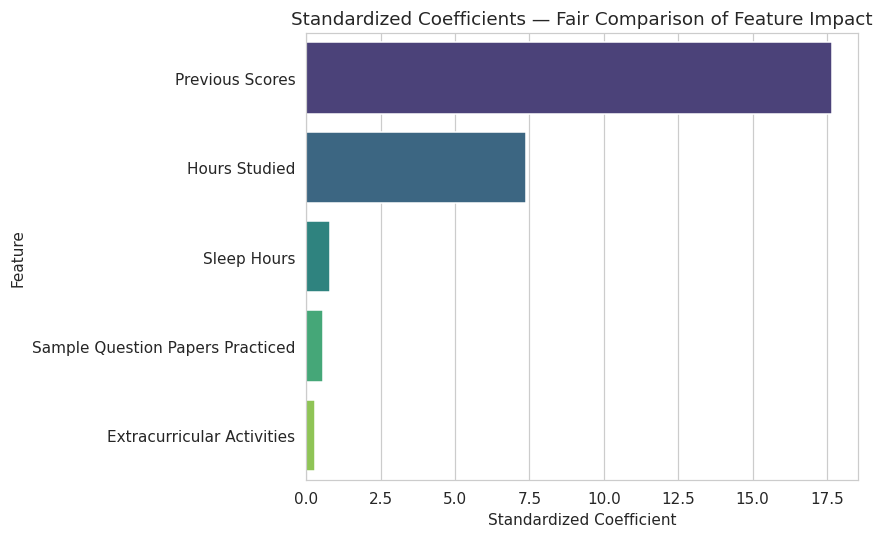

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(data=std_coeff_df, x="Standardized Coefficient", y="Feature",
            hue="Feature", palette="viridis", legend=False)
plt.title("Standardized Coefficients — Fair Comparison of Feature Impact")
plt.tight_layout()
plt.show()

With every feature put on the same scale first, the standardized coefficients show the *true*
relative importance: `Previous Scores` has the single largest effect on predicted performance, followed by
`Hours Studied` — both far ahead of `Extracurricular Activities`, `Sleep Hours`, and `Sample Question
Papers Practiced`, which each contribute comparatively little. This matches the earlier correlation heatmap
and confirms the model isn't relying on any one feature in a way the raw coefficients alone would have
hidden.

## 9. Residual diagnostics

For linear regression specifically, checking the residuals (actual minus predicted) matters more
than just the R² number — a good linear fit should show residuals scattered randomly around zero with no
pattern. A curve or funnel shape in this plot would suggest a linear model isn't actually appropriate for
the data. The original notebook had no residual plot at all.

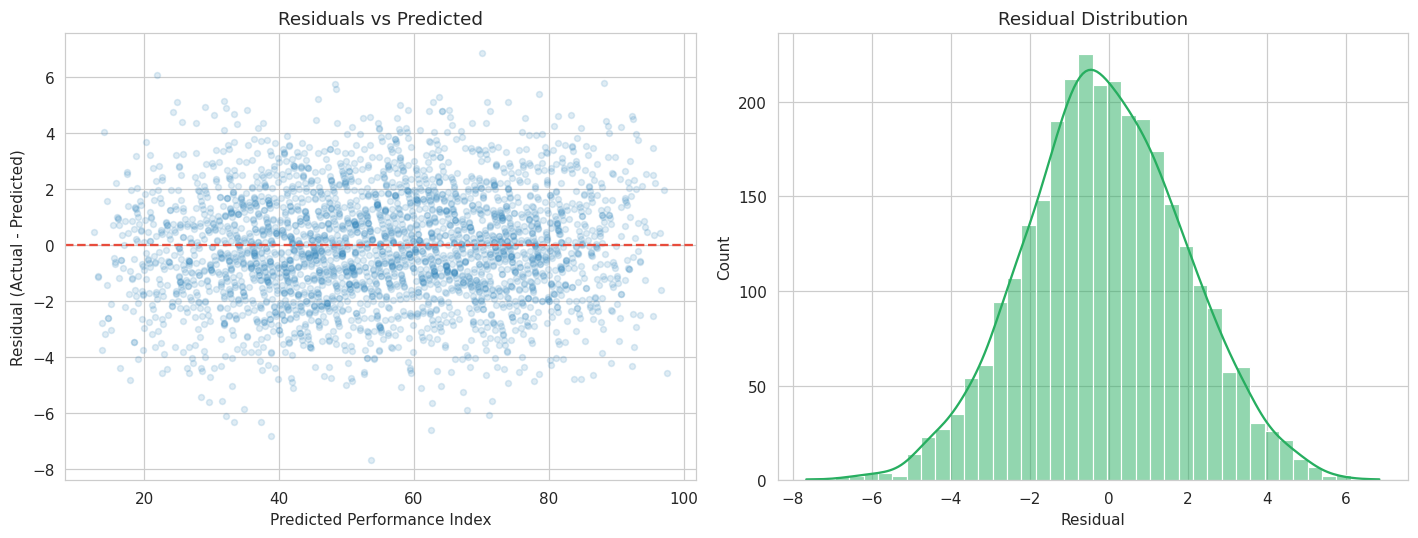

In [13]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred, residuals, alpha=0.15, s=15, color="#2980b9")
axes[0].axhline(0, color="#e74c3c", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Predicted Performance Index")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Residuals vs Predicted")

sns.histplot(residuals, bins=40, kde=True, color="#27ae60", ax=axes[1])
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

The residuals scatter randomly around zero with no funnel or curve shape, and their distribution is
roughly symmetric and bell-shaped — both are exactly what a well-fitted linear model should look like. This
is the visual confirmation behind the strong R² score, not just a number taken at face value.

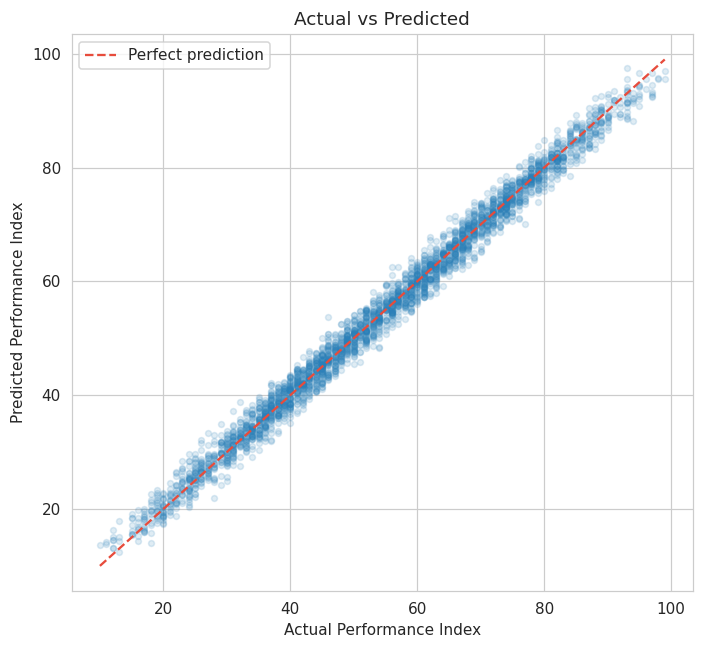

In [14]:
plt.figure(figsize=(6.5, 6))
plt.scatter(y_test, y_pred, alpha=0.15, s=15, color="#2980b9")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color="#e74c3c", linestyle="--", linewidth=1.5, label="Perfect prediction")
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Fixed custom prediction

In [15]:
def predict_performance(model, hours_studied, previous_scores, extracurricular,
                         sleep_hours, papers_practiced):
    """Predict Performance Index for a single new student, with named, labeled inputs."""
    row = pd.DataFrame([{
        "Hours Studied": hours_studied,
        "Previous Scores": previous_scores,
        "Extracurricular Activities": 1 if extracurricular == "Yes" else 0,
        "Sleep Hours": sleep_hours,
        "Sample Question Papers Practiced": papers_practiced
    }])
    prediction = model.predict(row)[0]
    return f"Predicted Performance Index: {prediction:.1f}"

print(predict_performance(reg, hours_studied=5, previous_scores=52,
                           extracurricular="No", sleep_hours=5, papers_practiced=2))

Predicted Performance Index: 36.0


**Fix from the original notebook:** `reg.predict([[5,52,0,5,2]])` had no labels — anyone reading it
has to manually count positions and cross-reference the column order to know what the 5 numbers even mean,
and it's one accidental reordering away from silently scoring the wrong feature against the wrong
coefficient. This version takes named arguments and builds the row explicitly.

## 11. Summary

- **Model actually evaluated**, unlike the original notebook: R² = 0.989, MAE = 1.61, RMSE = 2.02 on the
  held-out test set.
- **Removed dead/broken code**: the `df.isnull().sum` (missing parentheses) cell that would have printed a
  method reference instead of actual null counts.
- **`coeff_df` is now printed**, plus standardized coefficients added for a fair comparison of feature
  importance across differently-scaled features — `Previous Scores` and `Hours Studied` dominate, matching
  the correlation heatmap.
- **VIF multicollinearity check added**, including a fix for a common gotcha (VIF needs an intercept
  column, or the numbers come out misleadingly inflated). Result: all features are essentially independent
  (VIF ≈ 1.0), so the coefficients can be trusted at face value.
- **Residual diagnostics added** (residuals vs predicted, residual distribution, actual vs predicted) —
  specifically relevant for linear regression, to visually confirm a linear model is actually appropriate
  for this data rather than just trusting the R² number blindly.
- **Custom prediction fixed**: replaced a hardcoded, unlabeled list with a named function.
- **`LabelEncoder` on `Extracurricular Activities` confirmed correct as-is** — with only 2 categories,
  0/1 encoding doesn't introduce the false-ordering problem that would apply to a 3+ category nominal
  column.